In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
#from collections import namedtuple
import math
import ast
from scipy.stats import chisquare
from scipy import special
from scipy.optimize import minimize
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from shapely.geometry import LineString
from scipy.stats import crystalball
import scipy.special as sc
from iminuit import cost, Minuit
from numba_stats import crystalball, norm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 2)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2080<= dataframe3.iloc[i,9][1]< 2120):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_1tonne_single):
    NTD_data = []
    no_NTD_data = []

    NTD_data = []

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][j] in dataframe_1tonne_single.iloc[i,17]:
                NTD_data.append(i) 
            else:
                no_NTD_data.append(i) 

    NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    # for i in range(len(dataframe_1tonne_single)):
    #     for j in range(len(dataframe_1tonne_single.iloc[i,10])):
    #         if dataframe_1tonne_single.iloc[i,10][0] and dataframe_1tonne_single.iloc[i,10][1] not in dataframe_1tonne_single.iloc[i,17]:
    #             no_NTD_data.append(i) 

    no_NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    F_NTD = []
    E_NTD = []
    N_NTD = []
    C_NTD = []
    O_NTD = []
    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] == 'F':
            F_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'E':
            E_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'N':
            N_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'C':
            C_NTD.append(i)
        else:
            O_NTD.append(i)
            
    F_NTD = no_NTD_data[no_NTD_data.index.isin(F_NTD)]
    F_NTD=F_NTD.reset_index(drop=True)
    
    E_NTD = no_NTD_data[no_NTD_data.index.isin(E_NTD)]
    E_NTD=E_NTD.reset_index(drop=True)
    
    N_NTD = no_NTD_data[no_NTD_data.index.isin(N_NTD)]
    N_NTD=N_NTD.reset_index(drop=True)
    
    C_NTD = no_NTD_data[no_NTD_data.index.isin(C_NTD)]
    C_NTD=C_NTD.reset_index(drop=True)
    
    return F_NTD, E_NTD, C_NTD, N_NTD

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][1])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [5]:
def ChannelRemoval(dataframe):
    df = pd.read_csv('InvalidChannels/M2SE2104_InvalidChannelList.csv', sep=',')
    datasetlist = np.arange(3801, 3829)

    # Create a dictionary mapping each dataset to its channel list
    channel_map = df.groupby('Dataset')['Channels'].apply(list).to_dict()

    channel = []

    # Loop through the filtered datasets in dataframe_single
    for i in datasetlist:
        # Get the channel list for the dataset from the pre-built dictionary
        channel_list = channel_map.get(i, [])
        
        # Filter only rows in dataframe_single where the 'Dataset' equals the current dataset
        relevant_rows = dataframe[dataframe['Dataset'] == i]
        
        # Check for channel matches using vectorized apply with any()
        matches = relevant_rows.index[
            relevant_rows.iloc[:, 10].apply(lambda x: any(ch in channel_list for ch in x))
        ].tolist()
        
        # Add matching indices to the channel list
        channel.extend(matches)
        
    dataframe_reduced = dataframe.drop(channel)
    dataframe_reduced=dataframe_reduced.reset_index(drop=True)
        
    return dataframe_reduced
    

In [4]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_57176/3691485836.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_57176/2600934439.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_57176/2600934439.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

In [6]:
dataframe_reduced_single = ChannelRemoval(dataframe_single)
dataframe_reduced_single

,Dataset,Run,Channel,Tower,Layer,EventTime,Energy,TotalEnergy,Multiplicity,EnergyV,...,PCACut,EnergyVector,ChannelVector,FloorV,FloorVector,TowerV,TowerVector,LayerV,LayerVector,DeltaTVector
0,3801,350353,25,1,2,1494026501480,2100.202229,2607.162882,2,"[506.9606523449669, 2100.202229300007]",...,True,"[2100.202229300007, 506.9606523449669]","[25, 258]","[12, 11]","[12, 11]","[1, 5]","[1, 5]","[2, 1]","[2, 1]","[0.0, -4.6426818471445586e-05]"
1,3801,350353,30,1,1,1494028811104,2103.390024,2614.329107,2,"[510.93908232214835, 2103.3900242641107]",...,True,"[2103.3900242641107, 510.93908232214835]","[30, 69]","[4, 4]","[4, 4]","[1, 2]","[1, 2]","[1, 2]","[1, 2]","[0.0, 0.0013993162715451035]"
2,3801,350353,31,1,1,1494029544328,2099.978386,2623.224838,2,"[523.2464526129542, 2099.9783856920417]",...,True,"[2099.9783856920417, 523.2464526129542]","[31, 369]","[5, 5]","[5, 5]","[1, 8]","[1, 8]","[1, 1]","[1, 1]","[0.0, 0.0013504185390047496]"
3,3801,350353,41,1,2,1494031720696,2108.838182,2620.225614,2,"[511.38743256608024, 2108.838181517057]",...,True,"[2108.838181517057, 511.38743256608024]","[41, 172]","[2, 3]","[2, 3]","[1, 4]","[1, 4]","[2, 2]","[2, 2]","[0.0, 0.001163526465461473]"
4,3801,350353,44,1,1,1494042458840,2102.305644,2610.759184,2,"[508.45353919826454, 2102.3056443428254]",...,True,"[2102.3056443428254, 508.45353919826454]","[44, 173]","[5, 4]","[5, 4]","[1, 4]","[1, 4]","[1, 2]","[1, 2]","[0.0, 0.001741510997817386]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135584,3828,352373,940,19,2,1682459357632,2103.788363,2614.815853,2,"[511.02749044521767, 2103.7883629192293]",...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
135585,3828,352373,977,19,2,1682459787968,2103.881215,2619.341563,2,"[515.4603478827318, 2103.881215139123]",...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
135586,3828,352373,978,19,2,1682473942080,2105.686336,2616.460435,2,"[510.7740992240991, 2105.6863360387415]",...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
135587,3828,352373,967,19,2,1682483192464,2108.356041,2615.151212,2,"[506.7951708761215, 2108.356041074707]",...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
dataframe_reduced_3801 = dataframe_reduced_single[dataframe_reduced_single['Dataset']==3801]

for i in range(len(dataframe_reduced_3801)):
    if dataframe_reduced_3801.iloc[i,10][0] == 5 or dataframe_reduced_3801.iloc[i,10][1] == 5:
        print(i)

In [8]:
NTD_single, no_NTD_single = NTD_Sort(dataframe_reduced_single)
F_NTD, E_NTD, C_NTD, N_NTD= Topology_Sort(NTD_single)
F, E, C, N= Topology_Sort(no_NTD_single)

NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_single)
noNTD_2100, noNTD_511 = PrimarySecondarySplit(no_NTD_single)

In [9]:
def Double_Gaussian(x, mu, mu2, sigma, A, f, d):
    E0 = min(x)
    E1=max(x)
    Ec = (E0+E1)/2
    p = (1+A*(x-Ec))/(E1-E0)
    return (1-f-d)*norm.pdf(x,mu, sigma)+d*norm.pdf(x,mu2, sigma)+f*p

def Chi2(data, arr, bin_num):
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = Double_Gaussian(filtered_bin_centers, *arr)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Residual_Plot(data, arr, bin_num):
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = Double_Gaussian(filtered_bin_centers, *arr)*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)

def Minimizer(data, title, initial_parms, bin_num):
    c = cost.UnbinnedNLL(data, Double_Gaussian)

    E0 = min(data)
    E1 = max(data)
    Ec = (E0+E1)/2
    bound_A = 1/(Ec-E0)

    m = Minuit(c,*initial_parms)
    m.limits["f", "d"] = (0, 1)
    m.limits["mu", 'mu2', 'sigma'] = (0, None)
    m.limits["A"] = (-bound_A, bound_A)
    m.migrad()
    m.hesse()

    x_values = np.linspace(min(data), max(data), 1000)
    bin_width = (max(data) - min(data))/bin_num

    fig = plt.figure()
    ax=fig.add_axes((.1,.3,.8,.6))
    
    props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
    text = '\n'.join(( r'$\Delta\chi^2/ndf= $' + str(np.round(Chi2(data, m.values, bin_num), decimals=2)) +'/' +str(bin_num - (Double_Gaussian.__code__.co_argcount -1), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (PValue(bin_num - (Double_Gaussian.__code__.co_argcount -1),Chi2(data, m.values, bin_num)), ),
        'Entries: ' + (str(len(data))),
        r'$\mu=$ ' + str(np.round(m.values[0], decimals = 2) ) + '+-'+ str(np.round(m.errors[0], decimals = 2) ),
        r'$\mu_2=$ ' + str(np.round(m.values[1], decimals=2) ) + '+-'+ str(np.round(m.errors[1], decimals=2) ),
        r'$\sigma=$ ' + str(np.round(m.values[2], decimals = 2) ) + '+-'+ str(np.round(m.errors[2], decimals = 2) ),
        #r'$\sigma_2=$ ' + str(np.round(m.values[3], decimals = 2) ) + '+-'+ str(np.round(m.errors[3], decimals = 2) ),
        r'$A=$ ' + str(np.format_float_scientific(m.values[3], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[3], precision = 2) ),
        r'$f=$ ' + str(np.format_float_scientific(m.values[4], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[4], precision = 2) ),
        r'$d=$ ' + str(np.format_float_scientific(m.values[5], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[5], precision = 2) )
        ))
    
    mu, mu2,sigma, A,f,d = m.values
    muerr, mu2err,sigmaerr, Aerr,ferr,derr = m.errors

    ax.hist(data, bins = bin_num , histtype='step');
    ax.plot(x_values, Double_Gaussian(x_values,*m.values)*len(data)*bin_width,label='Fitted PDF', color='#000272')
    ax.plot(x_values, (1-f-d)*norm.pdf(x_values,mu, sigma)*len(data)*bin_width, label='Primary Gaussian', linestyle='--', color='#A72693')
    ax.plot(x_values, f*(1+A*(x_values-Ec))/(E1-E0)*len(data)*bin_width, label='Linear Bckg', linestyle='--', color='#BD512F')
    ax.plot(x_values, d*norm.pdf(x_values,mu2, sigma)*len(data)*bin_width, label='Secondary Gaussian', linestyle='--', color='#02383C')
    ax.legend(loc='upper right')
    ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
    ax.set_title(title)

    ax2=fig.add_axes((.1,.08,.8,.2))        
    ax2.errorbar(Residual_Plot(data, m.values, bin_num)[0],Residual_Plot(data, m.values, bin_num)[1], fmt='o',markersize=4)
    ax2.axhline(0, linestyle='--', color='crimson')
    
    return mu, muerr, sigma, sigmaerr, Chi2(data, m.values, bin_num)
    
def MinimizerTopologies(data, topologies, initial_parms):
    fitarr = []
    errorarr = []
    PDFs = []
    guass1 = []
    guass2 = []
    linear = []
    xvals = []
    bin_num = []
    bin_width = []

    for i in range(len(data)):
        E0 = min(data[i])
        E1 = max(data[i])
        Ec = (E0+E1)/2
        bound_A = 1/(Ec-E0)
        c = cost.UnbinnedNLL(data[i], Double_Gaussian)
        m = Minuit(c,*initial_parms[i])
        m.limits["f", "d"] = (0, 1)
        m.limits["mu", 'mu2', 'sigma'] = (0, None)
        m.limits["A"] = (-bound_A, bound_A)
        m.migrad()
        m.hesse()
        
        fitarr.append(m.values)
        errorarr.append(m.errors)
        x_values = np.linspace(min(data[i]), max(data[i]), 1000)
        xvals.append(x_values)
        bin_num.append(2*int(E1-E0))
        
        bin_width.append((E1-E0)/(2*int(E1-E0)))

    chisq = []
    pvals = []
    means = []
    means2 = []
    sigmas = []
    # sigmas2 = []
    A = []
    f = []
    d = []

    meanserr = []
    means2err = []
    sigmaserr = []
    # sigmas2err = []
    Aerr= []
    ferr = []
    derr = []
        
    for i in range(len(fitarr)):
        E0 = min(data[i])
        E1 = max(data[i])
        Ec = (E0+E1)/2
        PDFs.append(Double_Gaussian(xvals[i],*fitarr[i])*len(data[i])*bin_width[i])
        guass1.append((1-fitarr[i][4]-fitarr[i][5])*norm.pdf(xvals[i],fitarr[i][0], fitarr[i][2])*len(data[i])*bin_width[i])
        guass2.append((fitarr[i][5])*norm.pdf(xvals[i],fitarr[i][1], fitarr[i][2])*len(data[i])*bin_width[i])
        linear.append(fitarr[i][4]*(1+fitarr[i][3]*(xvals[i]-Ec))/(E1-E0)*len(data[i])*bin_width[i])
        chisq.append(Chi2(data[i], fitarr[i], bin_num[i]))
        pvals.append(PValue(bin_num[i]-(Double_Gaussian.__code__.co_argcount -1), chisq[i]))
        
        means.append(fitarr[i][0])
        means2.append(fitarr[i][1])
        sigmas.append(fitarr[i][2])
        # sigmas2.append(fitarr[i][3])
        A.append(fitarr[i][3])
        f.append(fitarr[i][4])
        d.append(fitarr[i][5])
        
        meanserr.append(errorarr[i][0])
        means2err.append(errorarr[i][1])
        sigmaserr.append(errorarr[i][2])
        # sigmas2err.append(errorarr[i][3])
        Aerr.append(errorarr[i][3])
        ferr.append(errorarr[i][4])
        derr.append(errorarr[i][5])
        
        
        
    data = { 'Topologies': topologies,
        'Bin Num': bin_num,
    'Histogram Data': data,
        'X-axis': xvals,
        'Fit': PDFs,
        'Guass1': guass1,
        'Guass2': guass2,
        'Linear': linear,
        'Means': means,
        'Means2': means2,
        'Sigmas': sigmas,
        # 'Sigmas2': sigmas2,
        'A': A,
        'f': f,
        'd': d, 
        'Chi2': chisq,
        'p-value': pvals, 
        'Meanserr': meanserr,
        'Means2err': means2err,
        'Sigmaserr': sigmaserr,
        # 'Sigmas2err': sigmas2err,
        'Aerr': Aerr,
        'ferr': ferr,
        'derr': derr,}

    df = pd.DataFrame(data)
        
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    props = dict(boxstyle='round', facecolor='whitesmoke')
    for i, ax in enumerate(axs.flatten()):
        if i < len(df):
            divider = make_axes_locatable(ax)
            
            text = '\n'.join(( r'$\Delta\chi^2/ndf= $' + str(np.round(df['Chi2'][i], decimals=2)) +'/' +str(df['Bin Num'][i] - (Double_Gaussian.__code__.co_argcount -1), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (df['p-value'][i], ),
        'Entries: ' + (str(len(df['Histogram Data'][i]))),
        r'$\mu=$ ' + str(np.round(df['Means'][i], decimals = 2) ) + '+-'+ str(np.round(df['Meanserr'][i], decimals = 2) ),
        r'$\mu_2=$ ' + str(np.round(df['Means2'][i], decimals=2) ) + '+-'+ str(np.round(df['Means2err'][i], decimals=2) ),
        r'$\sigma=$ ' + str(np.round(df['Sigmas'][i], decimals = 2) ) + '+-'+ str(np.round(df['Sigmaserr'][i], decimals = 2) ),
        # r'$\sigma_2=$ ' + str(np.round(df['Sigmas2'][i], decimals = 2) ) + '+-'+ str(np.round(df['Sigmas2err'][i], decimals = 2) ),
        r'$A=$ ' + str(np.format_float_scientific(df['A'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['Aerr'][i], precision = 2) ),
        r'$f=$ ' + str(np.format_float_scientific(df['f'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['ferr'][i], precision = 2) ),
        r'$d=$ ' + str(np.format_float_scientific(df['d'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['derr'][i], precision = 2) )
        ))
            
            ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
            
            ax.hist(df['Histogram Data'][i], bins=df['Bin Num'][i], histtype='step')
            ax.plot(df['X-axis'][i], df['Fit'][i], label='Fitted PDF', color='#000272')
            ax.plot(df['X-axis'][i], df['Guass1'][i], label='Primary Gaussian', linestyle='--', color='#A72693')
            ax.plot(df['X-axis'][i], df['Guass2'][i], label='Secondary Gaussian', linestyle='--', color='#02383C')
            ax.plot(df['X-axis'][i], df['Linear'][i], label='Linear Background', linestyle='--', color='#BD512F')
            ax.set_title(df["Topologies"][i] + ' (0.5 keV bins)')
            ax.legend(loc='upper right')
            
            ax2 = divider.append_axes("bottom", size="30%", pad=0.05)
            ax.figure.add_axes(ax2)
            ax2.errorbar(Residual_Plot(df['Histogram Data'][i], fitarr[i], bin_num[i])[0],Residual_Plot(df['Histogram Data'][i], fitarr[i], bin_num[i])[1], fmt='o',markersize=4)
            ax2.axhline(0, linestyle='--', color='crimson')
            
    plt.tight_layout()
    plt.show()
    
    return df['Means'], df['Meanserr'], df['Sigmas'], df['Sigmaserr'], df['Chi2']
    

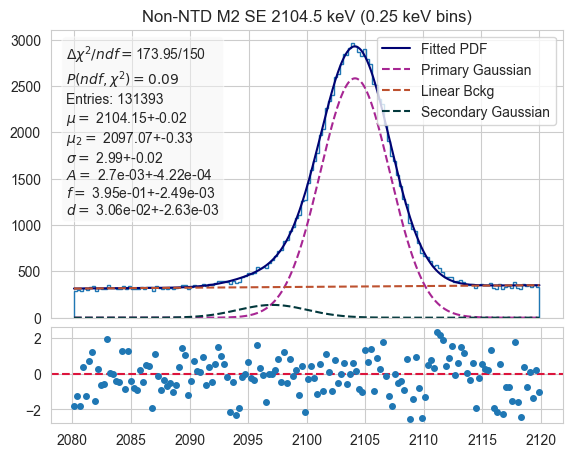

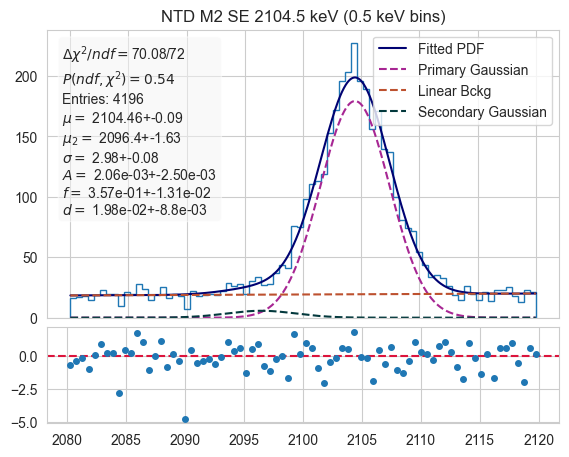

In [10]:
nonNTDmu, nonNTDmu_err, nonNTDsigma, nonNTDsigmaerr, nonNTDchi2 = Minimizer(np.asarray(noNTD_2100), 'Non-NTD M2 SE 2104.5 keV (0.25 keV bins)', [2104.4138503844847, 2095, 3.04, 1.71e-3, 0.1, 0.1], 4*int(max(noNTD_2100)-min(noNTD_2100)))
NTDmu, NTDmu_err, NTDsigma, NTDsigmaerr, NTDchi2 = Minimizer(NTD_2100, 'NTD M2 SE 2104.5 keV (0.5 keV bins)', [2104.4138503844847, 2095, 1.5, 1.71e-3, 0.1, 0.3], 2*int(max(noNTD_2100)-min(noNTD_2100)))

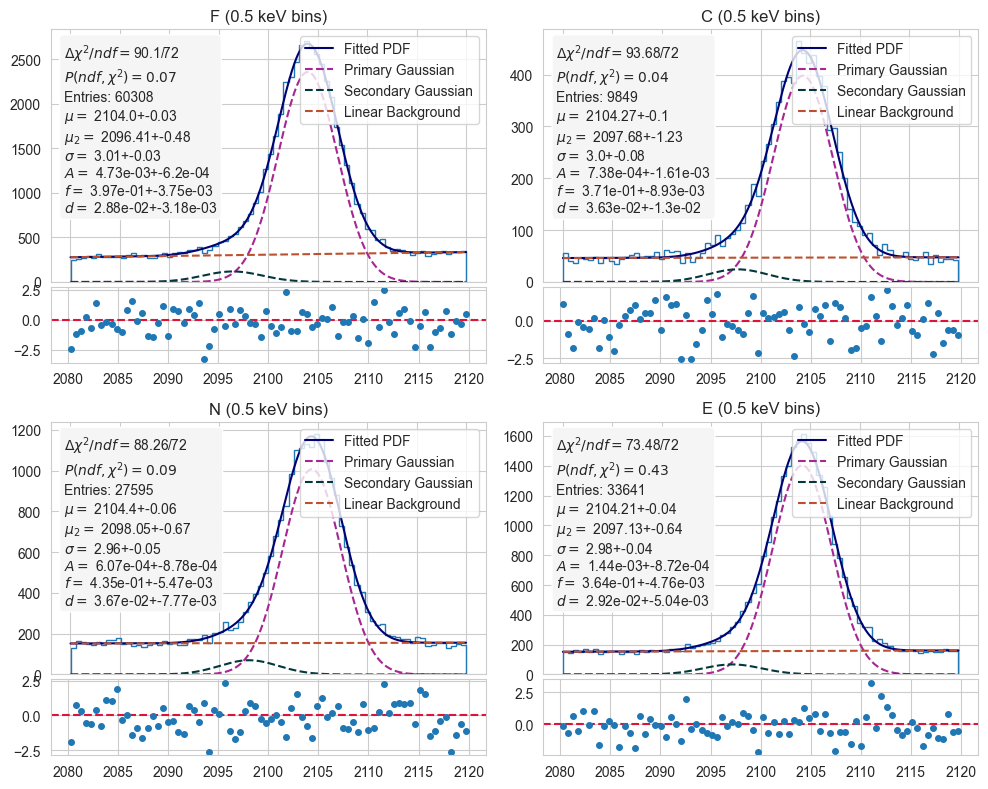

In [11]:
F_2100, F_511 = PrimarySecondarySplit(F)
C_2100, C_511 = PrimarySecondarySplit(C)
N_2100, N_511 = PrimarySecondarySplit(N)
E_2100, E_511 = PrimarySecondarySplit(E)

arr=[F_2100, C_2100, N_2100, E_2100]
topologies = ['F', 'C', 'N', 'E']

Finitial = [2104.4138503844847, 2095, 3.04, 1.71e-3, 0.1, 0.1]
Cinitial = [2104.4138503844847, 2095, 3.04, 1.71e-3, 0.1, 0.1]
Ninitial = [2104.4138503844847, 2095, 2.57, 1.71e-3, 0.1, 0.3]
Einitial = [2104.4138503844847, 2095, 3.04, 1.71e-3, 0.1, 0.1]

initial_parms = [Finitial, Cinitial, Ninitial, Einitial]

topologymeans, topologymeanerrors, topologysigmas, topologysigmaerros, chi2vals = MinimizerTopologies(arr, topologies, initial_parms)

# for i in range(len(arr)):
#     Minimizer(arr[i],topologies[i] )

In [73]:
def ExpectedVals(total_dataframe, dataframe):
        weights = [(((len(total_dataframe[total_dataframe['Dataset']==3801]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3801]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3802]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3802]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3803]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3803]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3804]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3804]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3805]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3805]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3806]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3806]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3807]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3807]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3808]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3808]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3809]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3809]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3810]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3810]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3811]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3811]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3812]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3812]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3813]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3813]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3814]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3814]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3815]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3815]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3816]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3816]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3817]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3817]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3818]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3818]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3819]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3819]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3820]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3820]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3821]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3821]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3822]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3822]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3823]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3823]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3824]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3824]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3825]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3825]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3826]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3826]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3827]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3827]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3828]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3828]))/len(dataframe))*100),
                   ]
        
        df_bias = pd.read_csv('Dataset-Info-ResBias/M2SE2104_bias_all.txt', sep=',', names=['Dataset', 'Bias', 'Bias_err'], header=None)
        df_res = pd.read_csv('Dataset-Info-ResBias/M2SE2104_reso_all.txt', sep=',', names=['Dataset', 'Res', 'Res_err'], header=None)
        
        mean_bias = 0
        sigma_res = 0
        
        for i in range(len(weights)):
                mean_bias += weights[i]*df_bias.iloc[i+1,1]
                sigma_res += weights[i]*df_res.iloc[i+1,1]
                
        average_means_bias = mean_bias/sum(weights)
        average_sigma_res = sigma_res/sum(weights)
        
        mean_bias_err = 0
        sigma_res_err = 0
        
        for i in range(len(weights)):
                mean_bias_err += (weights[i]*df_bias.iloc[i+1,2])**2
                sigma_res_err += (weights[i]*df_res.iloc[i+1,2])**2
        
        actual_mean_err = 1/sum(weights)*np.sqrt(mean_bias_err)
        actual_sigma_err = 1/sum(weights)*np.sqrt(sigma_res_err)
        
        
        return 2104.5+ average_means_bias, (average_sigma_res/2.355), actual_mean_err, actual_sigma_err*(1/2.355)

In [66]:
df_res = pd.read_csv('Dataset-Info-ResBias/M2SE2104_reso_all.txt', sep=',', names=['Dataset', 'Res', 'Res_err'], header=None)
df_bias = pd.read_csv('Dataset-Info-ResBias/M2SE2104_bias_all.txt', sep=',', names=['Dataset', 'Bias', 'Bias_err'], header=None)

In [74]:
expected_mean, expected_sigma, expected_mean_err, expected_sigma_err = ExpectedVals(dataframe_reduced_single, dataframe_reduced_single)
Fmean, Fsigma, Fmeanerr, Fsigmaerr = ExpectedVals(dataframe_reduced_single, F)
Cmean, Csigma, Cmeanerr, Csigmaerr = ExpectedVals(dataframe_reduced_single, C)
Emean, Esigma, Emeanerr, Esigmaerr = ExpectedVals(dataframe_reduced_single, E)
Nmean, Nsigma, Nmeanerr, Nsigmaerr = ExpectedVals(dataframe_reduced_single, N)

Text(0.5, 1.0, 'M2 Single 2104.5 keV Sigmas')

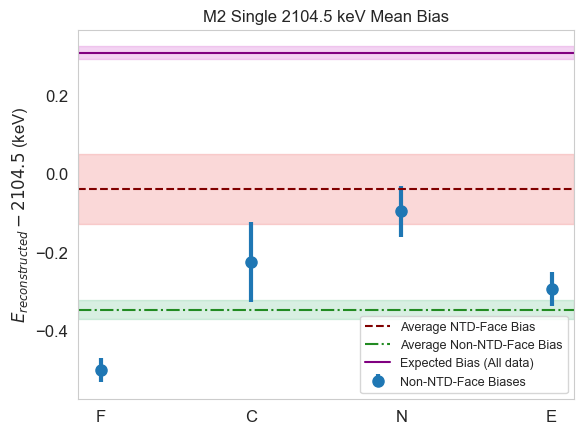

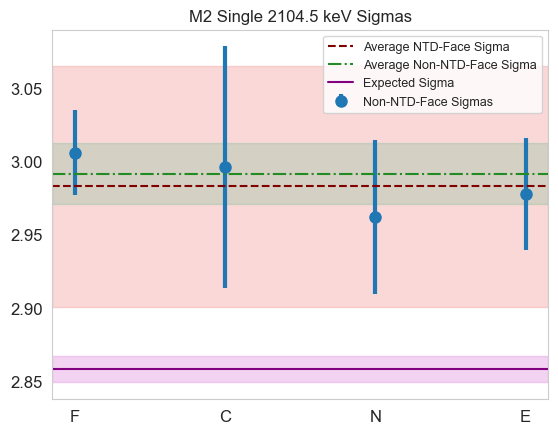

In [101]:
plt.figure()
plt.errorbar(topologies, topologymeans-2104.5, yerr=topologymeanerrors, ms=8, elinewidth=3, fmt='o', label='Non-NTD-Face Biases')
 # plt.errorbar(topologies, [Fmean, Cmean, Nmean, Emean], yerr=[Fmeanerr, Cmeanerr, Nmeanerr, Emeanerr], ms=8, elinewidth=3, fmt='^', color='darkslategrey', label='Non-NTD-Face Expected Means' )
# plt.errorbar(xNonNTD-0.13, topologymeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(NTDmu-2104.5 - NTDmu_err, NTDmu-2104.5 + NTDmu_err, color='lightcoral', alpha=0.3)
plt.axhline(NTDmu-2104.5, color='maroon', linestyle='--', label='Average NTD-Face Bias')

plt.axhspan(nonNTDmu-2104.5-nonNTDmu_err, nonNTDmu-2104.5+nonNTDmu_err, color='mediumseagreen', alpha=0.2)
plt.axhline(nonNTDmu-2104.5, color='forestgreen', linestyle='-.', label='Average Non-NTD-Face Bias')

plt.axhspan(expected_mean-2104.5 + expected_mean_err, expected_mean-2104.5 - expected_mean_err, color='orchid', alpha=0.3)
plt.axhline(expected_mean-2104.5, color='purple', linestyle='-', label='Expected Bias (All data)')

plt.legend(fontsize=9)
plt.ylabel(r'$E_{reconstructed}-2104.5$ (keV)', fontsize=12)

plt.xticks(np.arange(len(topologies)), topologies, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M2 Single 2104.5 keV Mean Bias')

plt.figure()
plt.errorbar(topologies, topologysigmas, yerr=topologysigmaerros, ms=8, elinewidth=3, fmt='o', label='Non-NTD-Face Sigmas')
# plt.errorbar(topologies, [Fsigma, Csigma, Nsigma, Esigma], yerr=[Fsigmaerr, Csigmaerr, Nsigmaerr, Esigmaerr], ms=8, elinewidth=3, fmt='^', color='darkslategrey', label='Non-NTD-Face Expected Sigmas' )
# plt.errorbar(xNonNTD-0.13, topologymeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(NTDsigma + NTDsigmaerr, NTDsigma - NTDsigmaerr, color='lightcoral', alpha=0.3)
plt.axhline(NTDsigma, color='maroon', linestyle='--', label='Average NTD-Face Sigma')

plt.axhspan(nonNTDsigma-nonNTDsigmaerr, nonNTDsigma+nonNTDsigmaerr, color='mediumseagreen', alpha=0.2)
plt.axhline(nonNTDsigma, color='forestgreen', linestyle='-.', label='Average Non-NTD-Face Sigma')

plt.axhspan(expected_sigma + expected_sigma_err, expected_sigma - expected_sigma_err, color='orchid', alpha=0.3)
plt.axhline(expected_sigma, color='purple', linestyle='-', label='Expected Sigma')

plt.legend(fontsize=9)

plt.xticks(np.arange(len(topologies)), topologies, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M2 Single 2104.5 keV Sigmas')

In [105]:
for i in range(len(topologymeans)):
    print(str(topologymeans[i]-2104.5) + '+-' + str(topologymeanerrors[i]))
    print(str(topologysigmas[i]) + '+-' + str(topologysigmaerros[i]))
    
print(expected_mean-2104.5)
print(expected_mean_err)
print(expected_sigma)
print(expected_sigma_err)

-0.501249758367976+-0.03138317176512828
3.0058455692651327+-0.02883570551601733
-0.22556664736839593+-0.10095915780243558
2.99589754480632+-0.08241365419498536
-0.09673470636562342+-0.06439976237334122
2.961982819618654+-0.05278481299191906
-0.29437944959909146+-0.04291984666679127
2.977900737142358+-0.038317122743783294
0.3079999999999927
0.015714935051519278
2.858245374582954
0.009060526958414672
